# 10 · Climate change: CO₂, radiation and temperature

Compare maize potential production at Gainesville under separate changes to CO₂, temperature and solar radiation.

## You will learn

- Set potential-production controls for one FileX treatment.
- Replace CO₂, add temperature and multiply radiation through environment modifications.
- Check weather output and compare grain yield and development dates.

In [1]:
LESSON = "10_climate_change"

In [2]:
# Connect to DSSAT and prepare a fresh copy of the lesson's data.
import os, shutil, subprocess, sys
from pathlib import Path
if "google.colab" in sys.modules:
    subprocess.run([sys.executable, "-m", "pip", "install", "dssatlab[course]>=0.23,<0.24"], check=True, capture_output=True)
    if Path.cwd().name != LESSON:
        if not Path("dssatlab").exists():
            subprocess.run(["git", "clone", "--depth", "1", "https://github.com/AbdelrahmanAmr3/dssatlab"], check=True)
        os.chdir(Path("dssatlab") / "course" / LESSON)
import dssatlab as dl
if "google.colab" in sys.modules:
    dl.install()
dssat = dl.connect()
HERE = Path.cwd()
RUNS = HERE / "runs"
if RUNS.exists():
    shutil.rmtree(RUNS)
_ = shutil.copytree(HERE / "data", RUNS)

Load the tools for tables and inline plots.

In [3]:
# Load the lesson tools.
import matplotlib.pyplot as plt
%matplotlib inline
print("Tools ready: tables and plots.")

Tools ready: tables and plots.


Select the copied stock inputs and check treatment 1 with water and nitrogen simulation off.

In [4]:
# Build and check the potential-production Simulation.
inputs = {
    "filex": RUNS / "UFGA8201.MZX",
    "weather": RUNS / "UFGA8201.WTH",
    "soil": RUNS / "SOIL.SOL",
    "executable": dssat,
}
controls = {"water": "N", "nitrogen": "N"}
baseline_experiment = {"treatments": {1: {"controls": controls, "environment": []}}}
sim = dl.Simulation(**inputs, treatment=1, management=baseline_experiment)
problems = sim.check(verbose=False)
print("Inputs:", ", ".join(inputs[key].relative_to(HERE).as_posix()
                          for key in ("filex", "weather", "soil")))
print("Problems:", problems)

Inputs: runs/UFGA8201.MZX, runs/UFGA8201.WTH, runs/SOIL.SOL
Problems: []


🌱 Crop idea  
Treatment 1 uses maize cultivar McCurdy 84aa (`IB0035`), planted on 26 February 1982.
Water and nitrogen simulation off removes those limits; this is potential production, not a rainfed yield forecast.

Run the default environment and show grain yield (`HWAM`, kg/ha), anthesis (`ADAT`) and maturity (`MDAT`).

In [5]:
# Run the default environment and read its Summary.
base_result = sim.run()
results = {"Default": base_result}
dl.to_dataframe(dl.read_summary(base_result.run_dir))[["TRNO", "PDAT", "HWAM", "ADAT", "MDAT"]]

,TRNO,PDAT,HWAM,ADAT,MDAT
0,1,1982-02-26,11859,1982-05-13,1982-07-04


Replace daily CO₂ with 550 ppm from the simulation start, keeping all other inputs fixed.

In [6]:
# Run the elevated-CO2 environment modification.
co2_experiment = {"treatments": {1: {
    "controls": controls,
    "environment": [{"date": "1982-02-25", "co2": {"replace": 550}}],
}}}
co2_sim = dl.Simulation(**inputs, treatment=1, management=co2_experiment, name="CO2 550")
co2_result = co2_sim.run()
results["CO2 550 ppm"] = co2_result
dl.to_dataframe(dl.read_summary(co2_result.run_dir))[["HWAM", "ADAT", "MDAT"]]

,HWAM,ADAT,MDAT
0,12349,1982-05-13,1982-07-04


🐍 Python idea  
`environment` is a list of dated changes; `replace` sets a daily value, `add` increases it and `multiply` scales it.
A change lasts until the next event; omitted variables stay unchanged for that event ([guide](../../docs/guide/experiment.md#environment-modifications)).

Add 2 °C to both daily maximum and minimum temperature, using default CO₂ and radiation.

In [7]:
# Run the warmer environment modification independently of elevated CO2.
warm_experiment = {"treatments": {1: {
    "controls": controls,
    "environment": [{"date": "1982-02-25", "tmax": {"add": 2}, "tmin": {"add": 2}}],
}}}
warm_sim = dl.Simulation(**inputs, treatment=1, management=warm_experiment, name="Warmer +2 C")
warm_result = warm_sim.run()
results["Temperature +2 C"] = warm_result
dl.to_dataframe(dl.read_summary(warm_result.run_dir))[["HWAM", "ADAT", "MDAT"]]

,HWAM,ADAT,MDAT
0,10186,1982-05-05,1982-06-24


Multiply daily solar radiation by 0.9 for 10% less radiation, using default CO₂ and temperatures.

In [8]:
# Run the reduced-radiation environment modification.
radiation_experiment = {"treatments": {1: {
    "controls": controls,
    "environment": [{"date": "1982-02-25", "srad": {"multiply": 0.9}}],
}}}
radiation_sim = dl.Simulation(**inputs, treatment=1, management=radiation_experiment,
                              name="Radiation x0.9")
radiation_result = radiation_sim.run()
results["Radiation x0.9"] = radiation_result
dl.to_dataframe(dl.read_summary(radiation_result.run_dir))[["HWAM", "ADAT", "MDAT"]]

,HWAM,ADAT,MDAT
0,10724,1982-05-13,1982-07-04


Read the same first simulation day from each weather output to confirm what DSSAT used.

In [9]:
# Compare effective CO2, temperature and radiation on 25 February.
weather_rows = []
for label, result in results.items():
    day = dl.read_weather(result.run_dir)[0]
    weather_rows.append({
        "Environment": label,
        "Date": day["DATE"],
        "CO2 (ppm)": day["CO2D"],
        "Tmax (C)": day["TMXD"],
        "Tmin (C)": day["TMND"],
        "Radiation (MJ/m2/day)": day["SRAD"],
    })
dl.to_dataframe(weather_rows)

,Environment,Date,CO2 (ppm),Tmax (C),Tmin (C),Radiation (MJ/m2/day)
0,Default,1982-02-25,340.7,27.2,10.6,14.8
1,CO2 550 ppm,1982-02-25,550.0,27.2,10.6,14.8
2,Temperature +2 C,1982-02-25,340.7,29.2,12.6,14.8
3,Radiation x0.9,1982-02-25,340.7,27.2,10.6,13.3


🌱 Crop idea  
The default here is 340.7 ppm on 25 February 1982, not today’s atmospheric CO₂.
Radiation is reported to one decimal place: 14.8 × 0.9 appears as 13.3 MJ/m²/day; the source weather file stays unchanged.

Compare all four yields against the default and include development dates and days from planting to maturity.

In [10]:
# Assemble the yield and development comparison.
comparison_rows = []
base_yield = dl.read_summary(base_result.run_dir)[0]["HWAM"]
for label, result in results.items():
    row = dl.read_summary(result.run_dir)[0]
    comparison_rows.append({
        "Environment": label,
        "HWAM (kg/ha)": row["HWAM"],
        "Change (kg/ha)": row["HWAM"] - base_yield,
        "Change (%)": round(100 * (row["HWAM"] - base_yield) / base_yield, 1),
        "Anthesis": row["ADAT"],
        "Maturity": row["MDAT"],
        "Days to maturity": (row["MDAT"] - row["PDAT"]).days,
    })
comparison = dl.to_dataframe(comparison_rows)
comparison

,Environment,HWAM (kg/ha),Change (kg/ha),Change (%),Anthesis,Maturity,Days to maturity
0,Default,11859,0,0.0,1982-05-13,1982-07-04,128
1,CO2 550 ppm,12349,490,4.1,1982-05-13,1982-07-04,128
2,Temperature +2 C,10186,-1673,-14.1,1982-05-05,1982-06-24,118
3,Radiation x0.9,10724,-1135,-9.6,1982-05-13,1982-07-04,128


🌱 Crop idea  
CO₂ at 550 ppm adds 490 kg/ha (+4.1%); 10% less radiation removes 1,135 kg/ha (-9.6%).
Warming removes 1,673 kg/ha (-14.1%) and brings maturity forward 10 days, consistent with a shorter growing period contributing to the lower yield; these outputs do not separate all temperature effects.

Plot the four separate environments to compare their potential grain yields.

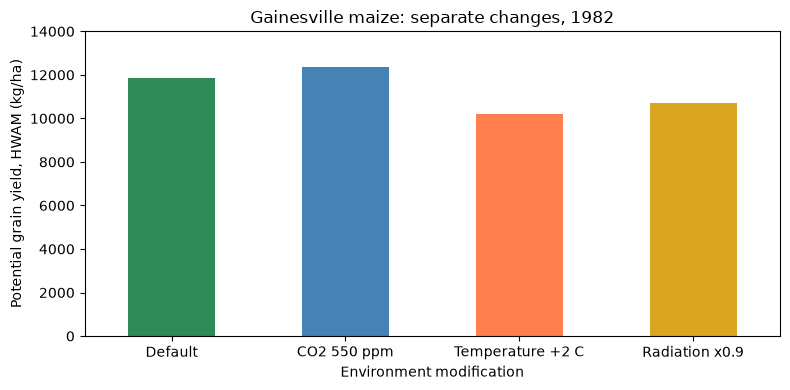

In [11]:
# Plot potential grain yield with units and a readable scale.
ax = comparison.plot.bar(x="Environment", y="HWAM (kg/ha)", legend=False,
                         color=["seagreen", "steelblue", "coral", "goldenrod"], figsize=(8, 4))
ax.set(xlabel="Environment modification", ylabel="Potential grain yield, HWAM (kg/ha)",
       title="Gainesville maize: separate changes, 1982", ylim=(0, 14000))
ax.tick_params(axis="x", labelrotation=0)
plt.tight_layout()
plt.show()

This one-season comparison isolates each change; it does not predict their combined effect or future farm yields.

## Your turn

Choose another elevated CO₂ concentration and compare it with the default potential yield.

Hint: edit `co2_ppm` (try 700), then run this cell on its own after setup and tools.

In [12]:
# Rebuild both simulations and compare your chosen CO2 concentration.
co2_ppm = 700
exercise_inputs = {
    "filex": RUNS / "UFGA8201.MZX",
    "weather": RUNS / "UFGA8201.WTH",
    "soil": RUNS / "SOIL.SOL",
    "executable": dssat,
}
exercise_controls = {"water": "N", "nitrogen": "N"}
exercise_base = {"treatments": {1: {"controls": exercise_controls, "environment": []}}}
exercise_change = {"treatments": {1: {
    "controls": exercise_controls,
    "environment": [{"date": "1982-02-25", "co2": {"replace": co2_ppm}}],
}}}
exercise_base_result = dl.Simulation(**exercise_inputs, treatment=1, management=exercise_base).run()
exercise_result = dl.Simulation(**exercise_inputs, treatment=1, management=exercise_change).run()
exercise_base_row = dl.read_summary(exercise_base_result.run_dir)[0]
exercise_row = dl.read_summary(exercise_result.run_dir)[0]
dl.to_dataframe([{
    "Chosen CO2 (ppm)": co2_ppm,
    "Default HWAM (kg/ha)": exercise_base_row["HWAM"],
    "Chosen HWAM (kg/ha)": exercise_row["HWAM"],
    "Change (kg/ha)": exercise_row["HWAM"] - exercise_base_row["HWAM"],
    "Chosen maturity": exercise_row["MDAT"],
}])

,Chosen CO2 (ppm),Default HWAM (kg/ha),Chosen HWAM (kg/ha),Change (kg/ha),Chosen maturity
0,700,11859,12455,596,1982-07-04


## Recap

- Water and nitrogen controls set to `"N"` provide a potential-production comparison.
- Dated environment modifications replace, add to or multiply daily values inside DSSAT.
- Weather output confirms the changes; yield and development dates show separate responses for this season.

Next: [11 · Nitrogen rates and N fixation](../11_nitrogen/lesson.ipynb).